In [95]:
import numpy as np
import torch
import torch.nn as nn
import torch.optim as optim
import matplotlib.pyplot as plt
import seaborn as sns

In [96]:
class MyModel(nn.Module):
    def __init__(self):
        super().__init__()
        self.layer1 = nn.Linear(2, 4)
        self.layer2 = nn.Linear(4, 4)
        self.layer3 = nn.Linear(4, 1)

    def forward(self, a):
        x = self.layer1(a)
        x = torch.relu(x) #4ro ka relu karega bcz 2 input hai aur 4 output

        x = self.layer2(x)
        x = torch.relu(x)

        x = self.layer3(x)

        return x

In [97]:

# x = torch.Tensor([[2., 1.], [5., 6.], [7., 9.], [11., 15.], [120., 110.]])
# y_real = torch.Tensor([[2.], [6.], [9.], [15.], [120.]])

x = torch.randint(1, 20, (1000, 2)).float()
y_real = torch.max(x[:, 0], x[:, 1]).unsqueeze(1)
loss_history = []
model = MyModel()
loss_fn = nn.MSELoss()
optimiser = optim.Adam(model.parameters(), 1)

In [98]:
i = 0
epoachs = 10_000
accuracy = 0.01
loss = torch.tensor(100000)

while loss.item() > accuracy:

    if i >= epoachs:
        break

    # Reset Gradients
    optimiser.zero_grad()

    # Forward Pass
    y_pred = model(x)

    # loss
    loss = loss_fn(y_pred, y_real)
    loss_history.append(loss.item())

    # Backward
    loss.backward()

    # Change Weights and biases
    optimiser.step()

    # Update iteration
    i += 1

print(f"Pass {i + 1} : loss = {loss.item()}")


Pass 10001 : loss = 20.538240432739258


In [99]:
def largest(a):
    if isinstance(a, torch.Tensor):
        x = a
    else:
        x = torch.tensor([a], dtype = torch.float32)

    with torch.no_grad():
        return round(model(x).item())

print(largest([[2, 9]]))
print(largest([[8, 3]]))
print(largest([[10, 10]]))
print(largest([[17, 4]]))
print(largest([[1, 19]]))

13
13
13
13
13


There are some fundamental problems I am encountering

1. Learning rate, sometimes it works else i have to tweak it randomly and pray it dosent take 10_000 passes or produces NaN
2. Problem 1 with bigger datasets with MLP, Batching and all will be a headache

i think we need to learn a bit about learning rates

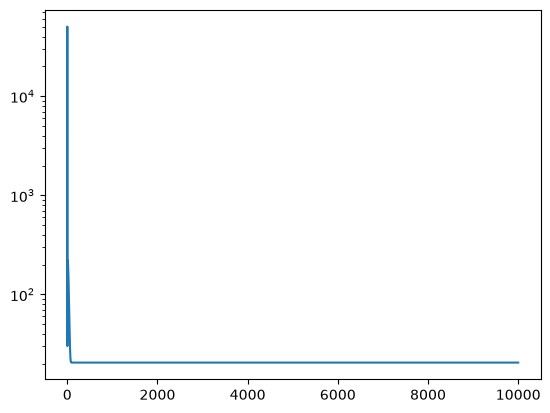

In [103]:
# Visualising Loss overtime
sns.lineplot(
    x = list(range(i)),
    y = loss_history
)
plt.yscale('log')
plt.show()


plt.show()